100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1064.90it/s]


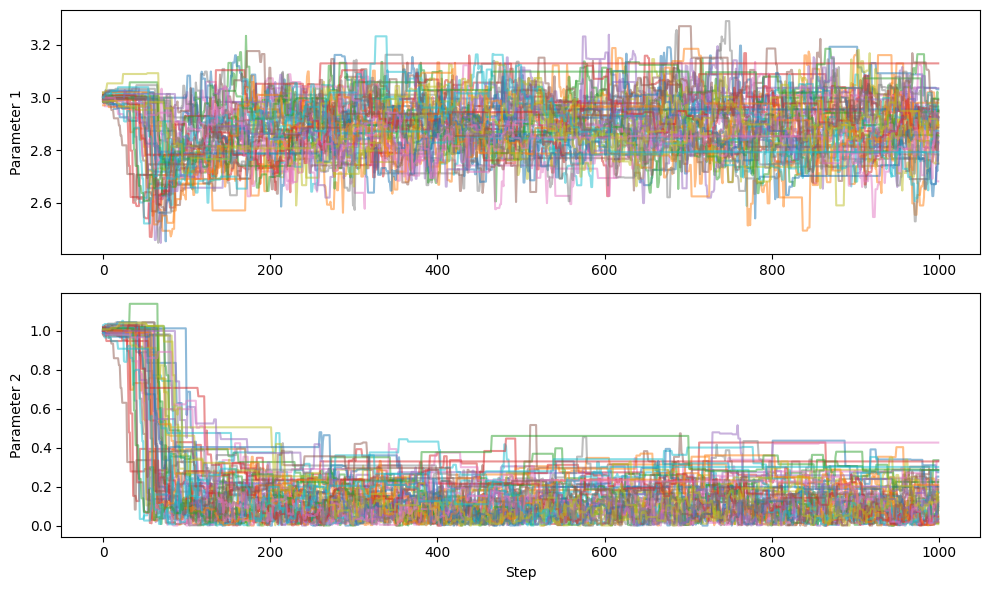

In [6]:
import emcee
import numpy as np
import matplotlib.pyplot as plt

# Sample data
np.random.seed(42)
data = np.random.normal(3, 1, 100)
def log_probability(theta, x):
    mu, sigma = theta
    
    # Ensure sigma (standard deviation) remains positive
    if sigma <= 0:
        return -np.inf  # Return negative infinity for invalid values
    
    model = np.random.normal(mu, sigma, len(x))
    return -0.5 * np.sum((x - model)**2)

# Define initial parameters and walkers
ndim = 2  # Number of parameters (mean, std deviation)
nwalkers = 50  # Number of walkers

initial = np.array([3.0, 1.0])  # Initial guess for parameters
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)  # Initial positions for walkers

# Set up the emcee sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(data,))

# Run MCMC with 1000 steps
sampler.run_mcmc(pos, 1000, progress=True)

# Get the samples
samples = sampler.get_chain()

# Plot the chains
plt.figure(figsize=(10, 6))
for i in range(ndim):
    plt.subplot(2, 1, i + 1)
    plt.plot(samples[:, :, i], alpha=0.5)
    plt.ylabel(f"Parameter {i+1}")
plt.xlabel("Step")
plt.tight_layout()
plt.show()
